<a href="https://colab.research.google.com/github/Zinniacodes01/Zinnia-s-Code/blob/main/text_classfication.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#imports
import os
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

In [ ]:
#imdb dataset: check wether a review is positive or negative
url = "https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"
dataset = tf.keras.utils.get_file("aclImdb_v1", url,
                                    untar=True, cache_dir='.',
                                    cache_subdir='')
dataset_dir = os.path.join(os.path.dirname(dataset), 'aclImdb')

84125825/84125825 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
print(dataset_dir)

./aclImdb


In [ ]:
dataset_dir='/content/aclImdb_v1/aclImdb'
train_dir_path=os.path.join(dataset_dir,'train')
test_dir_path=os.path.join(dataset_dir,'test')
print(os.listdir(train_dir_path))

['unsup', 'urls_neg.txt', 'neg', 'urls_unsup.txt', 'unsupBow.feat', 'pos', 'urls_pos.txt', 'labeledBow.feat']


In [ ]:
unsup_folder=os.path.join(train_dir_path,'unsup')
import shutil
shutil.rmtree(unsup_folder)
#removing unnneded unsup_folder which is part of the training folder

In [ ]:
train_data=tf.keras.utils.text_dataset_from_directory(train_dir_path,batch_size=32,validation_split=0.2,subset='training',seed=42)
validation_data=tf.keras.utils.text_dataset_from_directory(train_dir_path,batch_size=32,validation_split=0.2,subset='validation',seed=42)
test_data=tf.keras.utils.text_dataset_from_directory(test_dir_path,batch_size=32)#validation impt!!!
#loading the dataset

Found 25000 files belonging to 2 classes.
Using 20000 files for training.
Found 25000 files belonging to 2 classes.
Using 5000 files for validation.
Found 25000 files belonging to 2 classes.


Data Preprocessing

In [ ]:
for text_batch,label_batch in train_data.take(1):
  for n in range(5):#make 32
    print(text_batch.numpy()[n])
    print(train_data.class_names[label_batch.numpy()[n]])

b'"Pandemonium" is a horror movie spoof that comes off more stupid than funny. Believe me when I tell you, I love comedies. Especially comedy spoofs. "Airplane", "The Naked Gun" trilogy, "Blazing Saddles", "High Anxiety", and "Spaceballs" are some of my favorite comedies that spoof a particular genre. "Pandemonium" is not up there with those films. Most of the scenes in this movie had me sitting there in stunned silence because the movie wasn\'t all that funny. There are a few laughs in the film, but when you watch a comedy, you expect to laugh a lot more than a few times and that\'s all this film has going for it. Geez, "Scream" had more laughs than this film and that was more of a horror film. How bizarre is that?<br /><br />*1/2 (out of four)'
neg
b"David Mamet is a very interesting and a very un-equal director. His first movie 'House of Games' was the one I liked best, and it set a series of films with characters whose perspective of life changes as they get into complicated situat

In [ ]:
#standardization-easily processable data(different for every dataset!!!!!)
#1. lowercase everything
#2. remove punctuation
#3. remove html tags
import re
import string
def custom_standardization(text_data):
  #can't use .lower-it's tensorflow
  lower_text=tf.strings.lower(text_data)
  remove_html=tf.strings.regex_replace(lower_text, '<br />', ' ')
  remove_punctuation=tf.strings.regex_replace(remove_html, '[%s]'%re.escape(string.punctuation), '')
  return remove_punctuation


In [ ]:
#tokenization&vectorization
#dividing sentences into words & assigning them each a number
max_features=10000# 10,000(max number of words you can expect)
sequence_length=250 #if length below 250: fill in rest w/ 0's. elif length above 250: truncate(cut off the rest of) it
vectorize_layer=tf.keras.layers.TextVectorization(
    standardize=custom_standardization,
    max_tokens=max_features,
    output_mode='int',
    output_sequence_length=sequence_length
)#only add [] when tf.keras.sequential
train_text=train_data.map(lambda text,label: text)#instead of train_text containing text and label it will now only contain the text
vectorize_layer.adapt(train_text)

In [ ]:
def vectorize_text(text, label):
  text=tf.expand_dims(text, -1)#layers can only understand 2D arrays #does NOT mean take away 1 dimension
  return vectorize_layer(text), label

In [ ]:
for text_batch,label_batch in train_data.take(1):
  for n in range(5):#make 32
    print(text_batch.numpy()[n])
    print(train_data.class_names[label_batch.numpy()[n]])
    print(vectorize_text(text_batch.numpy()[n], label_batch.numpy()[n]))

b'Silent Night, Deadly Night 5 is the very last of the series, and like part 4, it\'s unrelated to the first three except by title and the fact that it\'s a Christmas-themed horror flick.<br /><br />Except to the oblivious, there\'s some obvious things going on here...Mickey Rooney plays a toymaker named Joe Petto and his creepy son\'s name is Pino. Ring a bell, anyone? Now, a little boy named Derek heard a knock at the door one evening, and opened it to find a present on the doorstep for him. Even though it said "don\'t open till Christmas", he begins to open it anyway but is stopped by his dad, who scolds him and sends him to bed, and opens the gift himself. Inside is a little red ball that sprouts Santa arms and a head, and proceeds to kill dad. Oops, maybe he should have left well-enough alone. Of course Derek is then traumatized by the incident since he watched it from the stairs, but he doesn\'t grow up to be some killer Santa, he just stops talking.<br /><br />There\'s a mysteri

In [ ]:
for n in range(50):
  print(n,vectorize_layer.get_vocabulary()[n])
print(len(vectorize_layer.get_vocabulary()))

0 
1 [UNK]
2 the
3 and
4 a
5 of
6 to
7 is
8 in
9 it
10 i
11 this
12 that
13 was
14 as
15 for
16 with
17 movie
18 but
19 film
20 on
21 not
22 you
23 are
24 his
25 have
26 be
27 he
28 one
29 its
30 all
31 at
32 by
33 an
34 they
35 from
36 who
37 so
38 like
39 her
40 just
41 or
42 about
43 has
44 out
45 if
46 some
47 there
48 what
49 good
10000


In [ ]:
train_ds=train_data.map(vectorize_text)#takes a function and applies it to every value in train_ds
test_ds=test_data.map(vectorize_text)
val_ds=validation_data.map(vectorize_text)

In [ ]:
train_ds=train_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds=val_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds=test_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
#based on the buffer size, it will prefech the data during the training

Model Creation & Training

In [ ]:
model=tf.keras.Sequential([
    tf.keras.layers.Embedding(10000,16),#helps model understand what id belongs to what vector(maps id to char/vector)
    tf.keras.layers.Dropout(0.2),#randomly drops 20% of the recieveing data to avoid overfitting(the model gets so much into the training data that it gets extremely well with training data but horrible with test data)
    tf.keras.layers.GlobalAveragePooling1D(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(1,activation='sigmoid')#binary go w/ one
])

In [ ]:
model.compile(loss=tf.keras.losses.BinaryCrossentropy(from_logits=False),optimizer='adam',metrics=['binary_accuracy'] )

In [ ]:
history=model.fit(train_ds,epochs=10,validation_data=val_ds)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - binary_accuracy: 0.6435 - loss: 0.6619 - val_binary_accuracy: 0.7354 - val_loss: 0.6103
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - binary_accuracy: 0.7784 - loss: 0.5468 - val_binary_accuracy: 0.8134 - val_loss: 0.4958
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - binary_accuracy: 0.8320 - loss: 0.4442 - val_binary_accuracy: 0.8334 - val_loss: 0.4249
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - binary_accuracy: 0.8573 - loss: 0.3805 - val_binary_accuracy: 0.8384 - val_loss: 0.3872
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - binary_accuracy: 0.8716 - loss: 0.3404 - val_binary_accuracy: 0.8476 - val_loss: 0.3599
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - binary_accuracy: 0.8814 - loss: 0.3101 - val_binary_accuracy: 0.8472 - val_loss: 0.3480
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - binary_accuracy: 0.8939 - loss: 0.2855 - val_binary_accuracy: 0.8578 - val_loss: 0.3289
Epoch 

In [ ]:
print(history.history)

{'binary_accuracy': [0.6435499787330627, 0.7784000039100647, 0.8320000171661377, 0.8573499917984009, 0.871649980545044, 0.8814499974250793, 0.8938500285148621, 0.9001500010490417, 0.9059000015258789, 0.9127500057220459], 'loss': [0.6618677973747253, 0.5467785000801086, 0.4442051351070404, 0.38052162528038025, 0.3404056131839752, 0.3101327121257782, 0.28553158044815063, 0.26702940464019775, 0.25077447295188904, 0.23694594204425812], 'val_binary_accuracy': [0.7354000210762024, 0.8133999705314636, 0.8334000110626221, 0.8384000062942505, 0.847599983215332, 0.8471999764442444, 0.8578000068664551, 0.8525999784469604, 0.86080002784729, 0.8637999892234802], 'val_loss': [0.6102675199508667, 0.49577796459198, 0.42491382360458374, 0.3872309625148773, 0.35987386107444763, 0.34800419211387634, 0.32888320088386536, 0.3284664750099182, 0.3171781599521637, 0.3120593726634979]}


In [ ]:
test_loss,test_accuracy=model.evaluate(test_ds)
print(test_loss)
print(test_accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - binary_accuracy: 0.8561 - loss: 0.3307
0.33065614104270935
0.8561199903488159


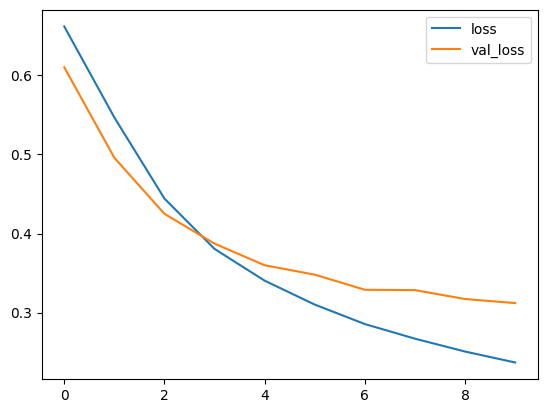

In [ ]:
plt.plot(history.history['loss'],label='loss')
plt.plot(history.history['val_loss'],label='val_loss')
plt.legend()

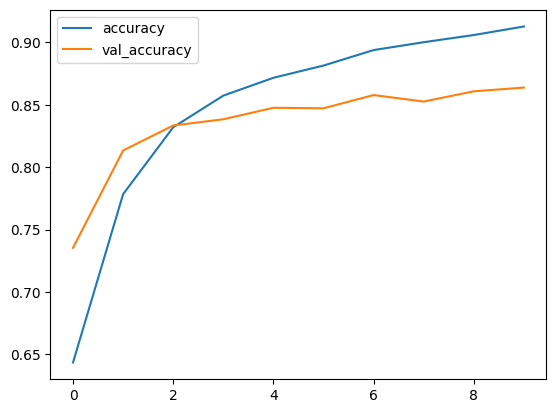

In [ ]:
plt.plot(history.history['binary_accuracy'],label='accuracy')
plt.plot(history.history['val_binary_accuracy'],label='val_accuracy')
plt.legend()

In [ ]:
new_review='If theres anything this movie proves, it is the difficulty in separating the series from the demands of fans. This is clear just from hearing some of the comments. Why didnt they identify the names on the Marauders Map? Why wasnt the second Quidditch game shown? Why wasnt there more of Crookshanks the Cat? By focusing on what the film didnt have, fans fail to look at the film on its own terms. I think this is by far the best Harry Potter movie yet.The only way to satisfy fans would be to include everything from the book, which would require a miniseries. Since that isnt what these films are, the story has to be abridged. The first two films tried to fit everything they could within a reasonable slot of time. The result was a set of films that felt cluttered yet incomplete. Had they continued with this strategy for this movie, based on a much longer book, it would surely have been over three hours long.The virtue of the latest film is that it makes a real attempt to adapt the story, not just marching in lockstep with the books events. The screenplay is sparing, leaving out or simplifying loads of details not directly relevant to the plot. But it captures much of the books delight and humor. The first two films fell short in this regard, because they lacked the guts to tinker with the details, even though that was the key to condensing the story while staying true to its spirit.The movie is still faithful to the book, of course. Many of the scenes are exactly as I had imagined them. When it deviates, it does so based on an understanding of the story and characters. This is evident in the way they show, for example, the Knight Bus; Hermiones overstuffed schedule; and the introduction of the Marauders Map, a scene that captures the twins mischievous personalities. The changes are clever and funny, and they help compensate for the movies loss in other areas.Certainly this has something to do with the new director. Columbuss approach was to stick to the books as literally as possible, often draining them of their subtlety. For instance, where the books only hint that Dumbledore can see through the invisibility cloak, the earlier movies make it unmistakable. The new director never condescends to the audience in that way. This is a childrens movie, but it is also a fantasy-thriller that we can take seriously, because not everything is spelled out for us. Were given a chance to think.But part of what makes the movie work is the book itself. The story is gripping from start to finish, because the threat looming over the school is established early on. Harrys personal life is sharply intertwined with the plot. We feel for him as we watch his disastrous (but hilarious) attempts to escape his uncle and aunt, and his humiliating reaction to the dementors. The story avoids common devices such as the talking killer or deus ex machina, which the other books have in abundance. The ending is nicely bittersweet and ambiguous. The plot is so complicated, however, that the book spends several chapters explaining it all. The movie wisely includes only very little of this, allowing the plot twists to become understood as the story progresses. I was surprised to see certain events that were in the movie but not the book lend support to an important theory some fans have had about what is to be revealed at the end of the series. Of course, it is well-hidden and wont give anything away for those who arent looking for the clues.I was so satisfied with the film that it almost seems trivial to mention the flaws, but there are some. The portrayal of Fudges assistant as the standard hunchbacked dimwit is out of place here, as it would be in anything other than a cartoon or spoof. The most serious misstep, though, is the casting of Michael Gambon as Dumbledore. Gambons face seems frozen in a perpetual nonexpression, and his voice lacks resonance. He compares poorly to the late Richard Harris, whose line readings had gravity, and who played the character with a twinkle in his eyes. It is a pure mystery to me why this actor was chosen as a replacement, especially considering the fine performances from other members of the cast. Even the children are in top form here.Those complaints aside, this is the movie I was hoping they would make when the series began. If it doesnt live up to the book, so what? Whats important is that it lives up to its potential as a movie. Fans who want a carbon-copy of the book are looking in the wrong place, because theyre never going to get it here. This is probably the best example of a Harry Potter movie that were ever likely to see.'
processed_review=vectorize_layer(new_review)
ready_review=tf.expand_dims(processed_review,0)#giving it to a layer so use tf.expand_dims
prediction=model.predict(ready_review)
if prediction[0]>0.5:
  print('pos')
else:
  print('neg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
neg


HW

In [ ]:
# imports
import os
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import re
import string
import shutil

# imdb dataset: check whether a review is positive or negative
url = "https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"
dataset = tf.keras.utils.get_file("aclImdb_v1", url, untar=True, cache_dir='.', cache_subdir='')
dataset_dir = os.path.join(os.path.dirname(dataset), 'aclImdb')

print(dataset_dir)

dataset_dir = '/content/aclImdb_v1/aclImdb'
train_dir_path = os.path.join(dataset_dir, 'train')
test_dir_path = os.path.join(dataset_dir, 'test')
print(os.listdir(train_dir_path))

unsup_folder = os.path.join(train_dir_path, 'unsup')
# removing unneeded unsup_folder which is part of the training folder
shutil.rmtree(unsup_folder)

# loading the dataset
train_data = tf.keras.utils.text_dataset_from_directory(train_dir_path, batch_size=32, validation_split=0.2, subset='training', seed=42)
validation_data = tf.keras.utils.text_dataset_from_directory(train_dir_path, batch_size=32, validation_split=0.2, subset='validation', seed=42)
test_data = tf.keras.utils.text_dataset_from_directory(test_dir_path, batch_size=32)

for text_batch, label_batch in train_data.take(1):
    for n in range(5):  # make 32
        print(text_batch.numpy()[n])
        print(train_data.class_names[label_batch.numpy()[n]])

# standardization - easily processable data (different for every dataset!!!!!)
# 1. lowercase everything
# 2. remove punctuation
# 3. remove html tags
def custom_standardization(text_data):
    # can't use .lower - it's tensorflow
    lower_text = tf.strings.lower(text_data)
    remove_html = tf.strings.regex_replace(lower_text, '<br />', ' ')
    remove_punctuation = tf.strings.regex_replace(remove_html, '[%s]' % re.escape(string.punctuation), '')
    return remove_punctuation

# tokenization & vectorization
# dividing sentences into words & assigning them each a number
max_features = 10000  # 10,000 (max number of words you can expect)
sequence_length = 250  # if length below 250: fill in rest w/ 0's. elif length above 250: truncate (cut off the rest of) it

vectorize_layer = tf.keras.layers.TextVectorization(
    standardize=custom_standardization,
    max_tokens=max_features,
    output_mode='int',
    output_sequence_length=sequence_length
)  # only add [] when tf.keras.sequential

train_text = train_data.map(lambda text, label: text)  # instead of train_text containing text and label it will now only contain the text
vectorize_layer.adapt(train_text)

def vectorize_text(text, label):
    text = tf.expand_dims(text, -1)  # layers can only understand 2D arrays # does NOT mean take away 1 dimension
    return vectorize_layer(text), label

for text_batch, label_batch in train_data.take(1):
    for n in range(5):  # make 32
        print(text_batch.numpy()[n])
        print(train_data.class_names[label_batch.numpy()[n]])
        print(vectorize_text(text_batch.numpy()[n], label_batch.numpy()[n]))

# Prediction logic snippet on a new review
new_review = "..."  # placeholder text for evaluation
processed_review = vectorize_layer(new_review)
ready_review = tf.expand_dims(processed_review, 0)  # giving it to a layer so use tf.expand_dims
prediction = model.predict(ready_review)

if prediction[0] > 0.5:
    print('pos')
else:
    print('neg')

HW

In [ ]:
import os
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import re
import string
import shutil
import pandas as pd

train_df = pd.read_csv('train.csv.zip')
test_df = pd.read_csv('test.csv.zip')

train_df['text'] = train_df['Title'] + " " + train_df['Description']
test_df['text'] = test_df['Title'] + " " + test_df['Description']

train_df['Class Index'] = train_df['Class Index'] - 1
test_df['Class Index'] = test_df['Class Index'] - 1

val_df = train_df.sample(frac=0.2, random_state=42)
train_df = train_df.drop(val_df.index)

class_names = ['World', 'Sports', 'Business', 'Sci/Tech']

train_data = tf.data.Dataset.from_tensor_slices((train_df['text'].values, train_df['Class Index'].values)).batch(32)
validation_data = tf.data.Dataset.from_tensor_slices((val_df['text'].values, val_df['Class Index'].values)).batch(32)
test_data = tf.data.Dataset.from_tensor_slices((test_df['text'].values, test_df['Class Index'].values)).batch(32)

for text_batch, label_batch in train_data.take(1):
    for n in range(5):
        print(text_batch.numpy()[n].decode('utf-8'))
        print("Class:", class_names[label_batch.numpy()[n]])
        print("-" * 50)

def custom_standardization(text_data):
    lower_text = tf.strings.lower(text_data)
    clean_text = tf.strings.regex_replace(lower_text, '\\\\', ' ')
    remove_punctuation = tf.strings.regex_replace(clean_text, '[%s]' % re.escape(string.punctuation), '')
    return remove_punctuation

max_features = 10000
sequence_length = 250

vectorize_layer = tf.keras.layers.TextVectorization(
    standardize=custom_standardization,
    max_tokens=max_features,
    output_mode='int',
    output_sequence_length=sequence_length
)

train_text = train_data.map(lambda text, label: text)
vectorize_layer.adapt(train_text)

def vectorize_text(text, label):
    text = tf.expand_dims(text, -1)
    return vectorize_layer(text), label

model = tf.keras.Sequential([
    tf.keras.layers.Embedding(max_features, 16),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.GlobalAveragePooling1D(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(4, activation='softmax')
])

model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    optimizer='adam',
    metrics=['sparse_categorical_accuracy']
)

train_ds = train_data.map(vectorize_text)
val_ds = validation_data.map(vectorize_text)
test_ds = test_data.map(vectorize_text)

epochs = 10
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

loss, accuracy = model.evaluate(test_ds)
print("Test Loss:", loss, "Test Accuracy:", accuracy)

new_article = "SpaceX launched another batch of satellites into orbit this morning."
processed_article = vectorize_layer(new_article)
ready_article = tf.expand_dims(processed_article, 0)

prediction = model.predict(ready_article)

predicted_class_index = np.argmax(prediction[0])
print("\n--- Custom Single Prediction ---")
print(new_article)
print(class_names[predicted_class_index])

Carlyle Looks Toward Commercial Aerospace (Reuters) Reuters - Private investment firm Carlyle Group,\which has a reputation for making well-timed and occasionally\controversial plays in the defense industry, has quietly placed\its bets on another part of the market.
Class: Business
--------------------------------------------------
Oil and Economy Cloud Stocks' Outlook (Reuters) Reuters - Soaring crude prices plus worries\about the economy and the outlook for earnings are expected to\hang over the stock market next week during the depth of the\summer doldrums.
Class: Business
--------------------------------------------------
Oil prices soar to all-time record, posing new menace to US economy (AFP) AFP - Tearaway world oil prices, toppling records and straining wallets, present a new economic menace barely three months before the US presidential elections.
Class: Business
--------------------------------------------------
Stocks End Up, But Near Year Lows (Reuters) Reuters - Stocks end

In [ ]:
import numpy as np
import tensorflow as tf
import pandas as pd
import string
train_df=pd.read_csv('train.csv.zip')
test_df=pd.read_csv('test.csv.zip')
train_df['text']=train_df['Description']
train_df['Class Index']-=1
test_df['text']=test_df['Description']
test_df['Class Index']-=1
val_df=train_df.sample(frac=0.2, random_state=42)
train_df=train_df.drop(val_df.index)
class_names=['World', 'Sports', 'Business', 'Sci/Tech']
train_data=tf.data.Dataset.from_tensor_slices((train_df['text'].values, train_df['Class Index'].values)).batch(32)
validation_data=tf.data.Dataset.from_tensor_slices((val_df['text'].values, val_df['Class Index'].values)).batch(32)
test_data=tf.data.Dataset.from_tensor_slices((test_df['text'].values, test_df['Class Index'].values)).batch(32)
for text_batch, label_batch in train_data.take(1):
    for n in range(5):
        print(text_batch.numpy()[n].decode('utf-8'))
        print(class_names[label_batch.numpy()[n]])
def custom_standardization(text_data):
    lower_text = tf.strings.lower(text_data)
    clean_text = tf.strings.regex_replace(lower_text, '\\\\', ' ')
    remove_punctuation = tf.strings.regex_replace(clean_text, '[%s]' % re.escape(string.punctuation), '')
    return remove_punctuation
max_features=10000
sequence_length=250
vectorize_layer = tf.keras.layers.TextVectorization(
    standardize=custom_standardization,
    max_tokens=max_features,
    output_mode='int',
    output_sequence_length=sequence_length
)
train_text = train_data.map(lambda text, label: text)
vectorize_layer.adapt(train_text)
def vectorize_text(text, label):
    text = tf.expand_dims(text, -1)
    return vectorize_layer(text), label
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(max_features, 16),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.GlobalAveragePooling1D(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(4, activation='softmax')
])
model.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),optimizer='adam',metrics=['sparse_categorical_accuracy'])
train_ds=train_data.map(vectorize_text)
val_ds=validation_data.map(vectorize_text)
test_ds=test_data.map(vectorize_text)
history=model.fit(train_ds,validation_data=val_ds,epochs=10)
loss, accuracy = model.evaluate(test_ds)
print(loss, accuracy)
new_article="SpaceX launched another batch of satellites into orbit this morning."
processed_article=vectorize_layer(new_article)
ready_article = tf.expand_dims(processed_article, 0)
prediction = model.predict(ready_article)
predicted_class_index = np.argmax(prediction[0])
print(new_article)
print(class_names[predicted_class_index])

Reuters - Private investment firm Carlyle Group,\which has a reputation for making well-timed and occasionally\controversial plays in the defense industry, has quietly placed\its bets on another part of the market.
Business
Reuters - Soaring crude prices plus worries\about the economy and the outlook for earnings are expected to\hang over the stock market next week during the depth of the\summer doldrums.
Business
AFP - Tearaway world oil prices, toppling records and straining wallets, present a new economic menace barely three months before the US presidential elections.
Business
Reuters - Stocks ended slightly higher on Friday\but stayed near lows for the year as oil prices surged past  #36;46\a barrel, offsetting a positive outlook from computer maker\Dell Inc. (DELL.O)
Business
AP - Assets of the nation's retail money market mutual funds fell by  #36;1.17 billion in the latest week to  #36;849.98 trillion, the Investment Company Institute said Thursday.
Business
Epoch 1/10
3000/300